In [2]:
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

Build network represented on Fig. 1

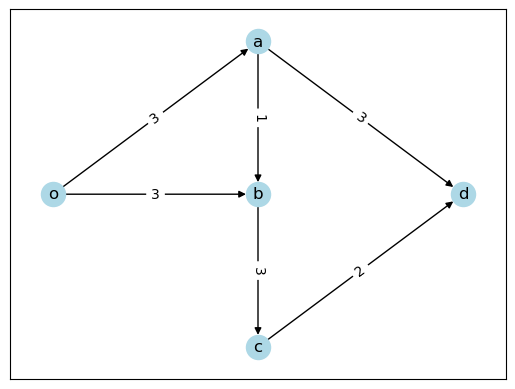

In [3]:
DG = nx.DiGraph()
link_list=[
    ('o','a',3),
    ('a','d',3),
    ('o','b',3),
    ('b','c',3),    
    ('c','d',2),    
    ('a','b',1),    
]
DG.add_weighted_edges_from(link_list)
DG['o']['a']['capacity'] = 3
DG['o']['b']['capacity'] = 3
DG['a']['d']['capacity'] = 3
DG['a']['b']['capacity'] = 1
DG['b']['c']['capacity'] = 3
DG['c']['d']['capacity'] = 2
pos = {'o': [0,1], 'a': [1,2], 'b': [1,1], 'c': [1,0], 'd': [2,1]}
labels = ['3','3','1','3','3','2']
nx.draw_networkx_nodes(DG, pos, node_color ='lightblue')

nx.draw_networkx_labels(DG, pos)

nx.draw_networkx_edges(DG, pos, arrows=True, width=1)

edge_cap = nx.get_edge_attributes(DG, 'capacity')
nx.draw_networkx_edge_labels(DG, pos, edge_labels=edge_cap);



#### 1.A) Compute the capacity of all the cuts and find the minimum capacity to be removed for no feasible flow from o to d to exist

A cut o-d partition $V$ in two subset $U$ and $V\setminus U$ and the capacity of the cut is given by the sum of the links belonging to out-boundary of $U$
$$
\partial_{U} = \{\, e \in \mathcal{E} : \theta(e) \in U,\; k(e) \in V \setminus U \,\}
$$
$$
    C_{U} := \sum_{e \in \partial_{U}}c_{e}
$$
the network resilience, the minimum total capacity to be removed from the network to make d not reachable from o, coincides with the min-cut capacity. So first compute the capacity of cuts
- $U=\{o,a,b,c\},U^C=\{d\}$ -> $C_U = 5$
- $U=\{o,b,c\},U^C=\{a,d\}$ -> $C_U = 5$
- $U=\{o,b\},U^C=\{a,c,d\}$ -> $C_U = 6$
- $U=\{o,a\},U^C=\{b,c,d\}$ -> $C_U = 7$
- $U=\{o\},U^C=\{a,b,c,d\}$ -> $C_U = 6$,

In [ ]:
import itertools

# ===============================================================
# (1) is_internal_reachable_set()
# ---------------------------------------------------------------
# Goal:
#   Check whether a subset of nodes U is internally reachable from the source node s.
#
# Logic:
#   1. U must contain the source node s.
#   2. Starting from s, perform a DFS (or BFS) restricted to nodes in U.
#   3. If all nodes in U are reachable from s within U, then U is "internally closed"
#      and therefore valid.
#   4. Otherwise, if any node in U cannot be reached using only nodes of U, 
#      it means an intermediate node is missing → U is invalid.
# ===============================================================
def is_internal_reachable_set(G: nx.DiGraph, U: set, s) -> bool:
    """Return True if every node in U is reachable from s using only nodes inside U."""
    if s not in U:
        return False
    seen = {s}
    stack = [s]
    while stack:
        u = stack.pop()
        for v in G.successors(u):
            if v in U and v not in seen:
                seen.add(v)
                stack.append(v)
    return seen == U  # All nodes in U are reachable from s within U


# ===============================================================
# (2) cut_capacity_and_edges()
# ---------------------------------------------------------------
# Goal:
#   Compute the total capacity of a given cut (U, V\U) and the list of edges that cross it.
#
# Logic:
#   1. Identify the complement T = V \ U.
#   2. For every node u in U, check each outgoing edge (u, v).
#   3. If v ∈ T (the other side of the cut), that edge contributes to the cut capacity.
#   4. Sum all such edge capacities and store the list of cut edges.
# ===============================================================
def cut_capacity_and_edges(G: nx.DiGraph, U: set, cap: str = 'capacity'):
    """Return the total capacity and edge list for the cut (U, V\\U)."""
    T = set(G.nodes()) - U
    cap_sum = 0
    cut_edges = []
    for u in U:
        for v in G.successors(u):
            if v in T:
                w = G[u][v].get(cap, 0)
                cap_sum += w
                cut_edges.append((u, v))
    return cap_sum, tuple(cut_edges)


# ===============================================================
# (3) enumerate_valid_cuts()
# ---------------------------------------------------------------
# Goal:
#   Enumerate all possible subsets U ⊆ V such that:
#     - s ∈ U, t ∉ U  (source is inside, sink is outside)
#     - U is internally reachable from s (no missing intermediate nodes)
#
# Logic:
#   1. List all nodes except s and t (they are fixed).
#   2. Generate all possible combinations of these nodes (power set).
#   3. For each combination:
#        a. Add s to form U.
#        b. Skip if t ∈ U.
#        c. Check internal reachability: if False → skip.
#        d. If valid, compute capacity and edge list.
#   4. Return all valid cuts with their attributes.
#
# Complexity:
#   Exponential in number of nodes (2^(n-2)), but fine for small graphs.
# ===============================================================
def enumerate_valid_cuts(G: nx.DiGraph, s, t, cap: str = 'capacity'):
    """
    Generate all node subsets U that represent valid s–t cuts.
    A cut is valid if:
        (1) s ∈ U
        (2) t ∉ U
        (3) every node in U is reachable from s using only nodes in U
    """
    nodes = list(G.nodes())
    nodes.remove(s)
    if t in nodes:
        nodes.remove(t)

    valid_cuts = []
    # Generate all combinations of remaining nodes
    for r in range(len(nodes) + 1):
        for subset in itertools.combinations(nodes, r):
            U = set(subset) | {s}
            if t in U:
                continue
            # Condition check: internal reachability closure
            if not is_internal_reachable_set(G, U, s):
                continue  # Skip illegal combinations (missing intermediates)
            cap_sum, edges = cut_capacity_and_edges(G, U, cap=cap)
            valid_cuts.append({'U': U, 'cap': cap_sum, 'edges': edges})
    return valid_cuts


s, t = 'o', 'd'
cuts = enumerate_valid_cuts(DG, s, t, cap='capacity')
cuts.sort(key=lambda c: (c['cap'], sorted(c['U'])))

print("Number of valid cuts:", len(cuts))
print("First 5 valid cuts (sorted by capacity):")
for c in cuts[:5]:
    print(f"  cap={c['cap']}, U={sorted(c['U'])}, edges={c['edges']}")

if cuts:
    print("Minimum cut capacity (from valid combinations):", cuts[0]['cap'])


Number of valid cuts: 6
First 5 valid cuts (sorted by capacity):
  cap=5, U=['a', 'b', 'c', 'o'], edges=(('c', 'd'), ('a', 'd'))
  cap=5, U=['b', 'c', 'o'], edges=(('o', 'a'), ('c', 'd'))
  cap=6, U=['a', 'b', 'o'], edges=(('b', 'c'), ('a', 'd'))
  cap=6, U=['b', 'o'], edges=(('b', 'c'), ('o', 'a'))
  cap=6, U=['o'], edges=(('o', 'a'), ('o', 'b'))
Minimum cut capacity (from valid combinations): 5


In [5]:
# ===============================================================
# (5) Output of all minimum cuts
# ---------------------------------------------------------------
# Goal:
#   Instead of printing only the first minimum cut,
#   detect if there are multiple cuts with the same minimum capacity
#   and display all of them.
#
# Logic:
#   1. Sort all valid cuts by capacity (already done above).
#   2. Identify the minimum capacity value (cuts[0]['cap']).
#   3. Collect all cuts with that same capacity.
#   4. For each, compute V = all_nodes - U and print:
#        "capacity, {U}, {V}"
# ===============================================================
if cuts:
    min_cap = cuts[0]['cap']
    all_nodes = set(DG.nodes())

    # Collect all cuts with minimum capacity
    min_cuts = [c for c in cuts if c['cap'] == min_cap]

    print(f"Minimum cut capacity: {min_cap}")
    print("All minimum cuts (capacity, {U}, {V}):")
    for c in min_cuts:
        U = c['U']
        V = all_nodes - U
        print(f"  {min_cap}, {sorted(U)}, {sorted(V)}")
else:
    print("No valid cuts found.")


Minimum cut capacity: 5
All minimum cuts (capacity, {U}, {V}):
  5, ['a', 'b', 'c', 'o'], ['d']
  5, ['b', 'c', 'o'], ['a', 'd']


The minimal capacity that needs to be removed in order to disconnect nodes o-d equals the capacity of the min-cut of the network, which is 5.

#### 1.B)You are given x > 0 extra units of capacity (x ∈ Z). How should you distribute them in order to maximize the throughput that can be sent from o to d? Plot the maximum throughput from o to d as a function of x ≥ 0.

[x=0] max throughput = 5
[x=1] min-cut=5  +1 on ('c', 'd')  -> max throughput = 6
[x=2] min-cut=6  +1 on ('o', 'a')  -> max throughput = 6
[x=3] min-cut=6  +1 on ('a', 'd')  -> max throughput = 7
[x=4] min-cut=7  +1 on ('o', 'a')  -> max throughput = 7
[x=5] min-cut=7  +1 on ('a', 'd')  -> max throughput = 8
[x=6] min-cut=8  +1 on ('o', 'a')  -> max throughput = 8
[x=7] min-cut=8  +1 on ('a', 'd')  -> max throughput = 9
[x=8] min-cut=9  +1 on ('o', 'a')  -> max throughput = 9
[x=9] min-cut=9  +1 on ('a', 'd')  -> max throughput = 10
[x=10] min-cut=10  +1 on ('o', 'a')  -> max throughput = 10
[x=11] min-cut=10  +1 on ('a', 'd')  -> max throughput = 11
[x=12] min-cut=11  +1 on ('o', 'a')  -> max throughput = 11
[x=13] min-cut=11  +1 on ('a', 'd')  -> max throughput = 12
[x=14] min-cut=12  +1 on ('o', 'a')  -> max throughput = 12
[x=15] min-cut=12  +1 on ('a', 'd')  -> max throughput = 13
[x=16] min-cut=13  +1 on ('o', 'a')  -> max throughput = 13
[x=17] min-cut=13  +1 on ('a', 'd')  -> m

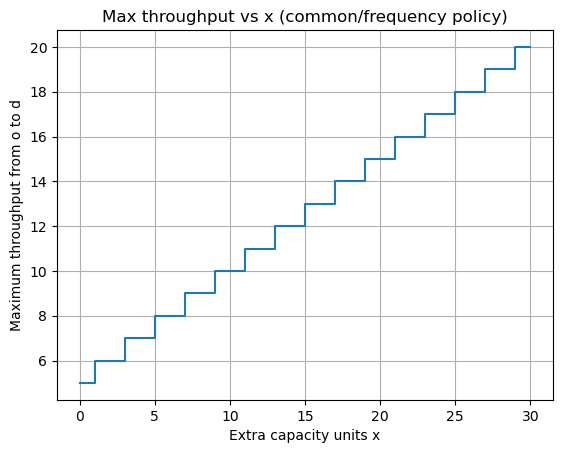

In [43]:
# ===============================================================
# (6) Functions for part 1.B – Incremental capacity allocation
# ---------------------------------------------------------------
# Goal:
#   Implement the logic for question 1.B:
#   "You are given x > 0 extra units of capacity (x ∈ Z). How should you distribute them
#    in order to maximize the throughput that can be sent from o to d?"
#
# Logic:
#   For each incremental unit (1..x):
#     1) Compute all minimum cuts using your existing functions.
#     2) If all min-cuts share common edges → increase one of those common edges.
#     3) Otherwise → increase the edge that appears in the highest number of min-cuts.
#        If there is still a tie, choose randomly among them.
#     4) After each increment, compute the new max flow and record it.
# ===============================================================

import random
from copy import deepcopy
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Utility: find min-cuts using existing enumerate_valid_cuts()
# ---------------------------------------------------------------
def find_min_cuts(G: nx.DiGraph, s, t, cap: str = 'capacity'):
    cuts = enumerate_valid_cuts(G, s, t, cap=cap)
    if not cuts:
        return None, []
    cuts.sort(key=lambda c: (c['cap'], sorted(c['U'])))
    min_cap = cuts[0]['cap']
    min_cuts = [c for c in cuts if c['cap'] == min_cap]
    return min_cap, min_cuts


# ---------------------------------------------------------------
# Count how often each edge appears in the list of min-cuts
# ---------------------------------------------------------------
def edge_frequency_in_cuts(min_cuts):
    freq = {}
    for c in min_cuts:
        for e in c['edges']:
            freq[e] = freq.get(e, 0) + 1
    return freq


# ---------------------------------------------------------------
# Choose the edge to increase according to the described rules
# ---------------------------------------------------------------
def choose_edge_to_increase(min_cuts, rng: random.Random | None = None, 
                            G: nx.DiGraph | None = None, s: int | None = None, t: int | None = None):
    """
    Choose which edge to increase among those appearing in the current min-cuts.

    Strategy:
      1) Compute how many min-cuts each edge appears in (frequency).
      2) Select the edges with maximum frequency (most critical edges).
      3) If multiple candidates have equal frequency:
            - If a graph G and nodes (s, t) are provided, 
              choose the edge with smallest total distance (s→u + v→t),
              meaning the edge lies closest to the main s–t flow.
            - Otherwise, choose deterministically by smallest edge index.
    """
    import random
    import networkx as nx

    if not min_cuts:
        return None
    if rng is None:
        rng = random

    # 1) Compute frequency of each edge across all min-cuts
    freq = edge_frequency_in_cuts(min_cuts)
    if not freq:
        return None

    # 2) Find the highest frequency value
    max_count = max(freq.values())

    # 3) Collect edges that appear most often among all min-cuts
    candidates = [e for e, count in freq.items() if count == max_count]

    # 4) Tie-breaking with optional topology information
    if len(candidates) > 1 and G is not None and s is not None and t is not None:
        try:
            # Precompute shortest-path distances from source and to target
            dist_s = nx.single_source_shortest_path_length(G, s)
            dist_t = nx.single_source_shortest_path_length(G.reverse(), t)

            # Compute score = dist(s,u) + dist(v,t)
            scores = {}
            for (u, v) in candidates:
                ds = dist_s.get(u, float('inf'))
                dt = dist_t.get(v, float('inf'))
                scores[(u, v)] = ds + dt

            # Pick edge with smallest total distance (closest to main flow)
            chosen = min(scores, key=scores.get)
            return chosen
        except Exception:
            # If distance computation fails, fall back to deterministic tie-break
            pass

    # 5) Deterministic fallback: choose smallest edge index or tuple
    chosen = sorted(candidates)[0]
    return chosen




# ---------------------------------------------------------------
# Main allocation routine
# ---------------------------------------------------------------
def allocate_extra_capacity_iterative(
    G_in: nx.DiGraph, s, t, x: int, cap: str = 'capacity',
    seed: int | None = None, verbose: bool = True
):
    """
    Increment capacities one by one for x steps following the given logic.
    """
    G = deepcopy(G_in)
    rng = random.Random(seed) if seed is not None else random

    throughputs = []
    v0, _ = nx.maximum_flow(G, s, t, capacity=cap)
    throughputs.append(v0)
    if verbose:
        print(f"[x=0] max throughput = {v0}")

    history = []
    for i in range(1, x + 1):
        min_cap, min_cuts = find_min_cuts(G, s, t, cap=cap)
        edge = choose_edge_to_increase(min_cuts, rng=rng)
        if edge is None:
            history.append({'step': i, 'min_cap': min_cap, 'increased': None, 'flow': throughputs[-1]})
            if verbose:
                print(f"[x={i}] no edge to increase; flow stays {throughputs[-1]}")
            continue

        # increment the chosen edge
        u, v = edge
        G[u][v][cap] = G[u][v].get(cap, 0) + 1
        v_now, _ = nx.maximum_flow(G, s, t, capacity=cap)
        throughputs.append(v_now)
        history.append({'step': i, 'min_cap': min_cap, 'increased': (u, v), 'flow': v_now})

        if verbose:
            print(f"[x={i}] min-cut={min_cap}  +1 on {edge}  -> max throughput = {v_now}")

    return G, history, throughputs


# ---------------------------------------------------------------
# Plotting utility for F(x)
# ---------------------------------------------------------------
def plot_throughput(throughputs, title="Max throughput vs extra capacity x"):
    xs = list(range(len(throughputs)))  # includes x=0
    plt.figure()
    plt.step(xs, throughputs, where='post')
    plt.xlabel("Extra capacity units x")
    plt.ylabel("Maximum throughput from o to d")
    plt.title(title)
    plt.grid(True)
    plt.show()


# ===============================================================
# (7) Run incremental capacity allocation directly on existing DG
# ---------------------------------------------------------------
# Using the graph DG previously defined in the earlier cell.
# ===============================================================

s, t = 'o', 'd'

# Number of extra capacity units to allocate
x = 30

# Run the iterative allocation procedure
G_final, history, F = allocate_extra_capacity_iterative(DG, s, t, x=x, verbose=True)



# Plot F(x): maximum throughput vs extra capacity x
plot_throughput(F, title="Max throughput vs x (common/frequency policy)")


#### 1.C)You are given the possibility of adding to the network a directed link e8 with capacity c8 = 1 and x > 0 extra units of capacity (x ∈ Z). Where should you add the link and how should you distribute the additional capacity in order to maximize the throughput that can be sent from o to d? Plot the maximum throughput from o to d as a function of x ≥ 0.

#### 1.3) You are given the possibility of adding to the network a directed link e8 with capacity c8 = 1 and x > 0 extra units of capacity (x ∈ Z). Where should you add the link and how should you distribute the additional capacity in order to maximize the throughput that can be sent from o to d? Plot the maximum throughput from o to d as a function of x ≥ 0.

In [7]:
import networkx as nx
from copy import deepcopy

# ---------------------------------------------------------------
# Reachability utilities
# ---------------------------------------------------------------
def forward_reachable_nodes(G: nx.DiGraph, s):
    """Return all nodes reachable from s (forward DFS)."""
    seen = {s}
    stack = [s]
    while stack:
        u = stack.pop()
        for v in G.successors(u):
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return seen

def backward_reachable_nodes(G: nx.DiGraph, t):
    """Return all nodes that can reach t (via reverse DFS)."""
    GR = G.reverse(copy=False)
    seen = {t}
    stack = [t]
    while stack:
        u = stack.pop()
        for v in GR.successors(u):
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return seen

# ---------------------------------------------------------------
# Candidate new arcs (possible positions for e8)
# ---------------------------------------------------------------
def candidate_new_arcs(G: nx.DiGraph, s, t):
    """
    Return all valid candidate arcs (u, v) for e8:
      - u is forward-reachable from s
      - v is backward-reachable to t
      - (u, v) does not already exist
      - u != v
    """
    Rf = forward_reachable_nodes(G, s)
    Rb = backward_reachable_nodes(G, t)
    candidates = []
    for u in Rf:
        for v in Rb:
            if u != v and not G.has_edge(u, v):
                candidates.append((u, v))
    return candidates

# ---------------------------------------------------------------
# Count how many current min-cuts (U, V\U) are crossed by (u→v)
# ---------------------------------------------------------------
def count_cuts_crossed_by_arc(u, v, min_cuts):
    count = 0
    for c in min_cuts:
        U = c['U'] # Remember the cut are dictionary with keys: 'U':"list of nodes beloging to reachable set of the cut"
                                                            #   'capsum': capacity of the cut
                                                            #  'edges': list of edges that cross U and V\U set
        if u in U and v not in U:
            count += 1
    return count

# ---------------------------------------------------------------
# Evaluate the gain in max-flow if e8=(u,v) with capacity=1 is added
# ---------------------------------------------------------------
def evaluate_new_arc(G: nx.DiGraph, s, t, u, v, cap='capacity', c8=1):
    Gtmp = deepcopy(G)
    Gtmp.add_edge(u, v)
    Gtmp[u][v][cap] = c8
    val, _ = nx.maximum_flow(Gtmp, s, t, capacity=cap)
    return val

# ---------------------------------------------------------------
# Select the best location for the new link e8
# ---------------------------------------------------------------
def pick_best_new_link(G: nx.DiGraph, s, t, cap='capacity', c8=1):
    """
    Choose where to add e8 = (u→v) according to:
      (1) Maximum post-insertion max-flow value
      (2) Tie-break → crosses the largest number of current min-cuts
    """
    # Check current state of the graph (before add new link) in order to compare results after add new link
    base_flow, _ = nx.maximum_flow(G, s, t, capacity=cap)
    _, min_cuts = find_min_cuts(G, s, t, cap=cap)

    # Initialization of the variables of the results, best will contain the best edge, best flow how the flow increment and best cut hits
    # the number of min-cut coressed by that edge
    best = None
    best_flow = base_flow
    best_cut_hits = -1

    # The method "candidate_new_arcs" will return all potential and valid edges for e8
    for (u, v) in candidate_new_arcs(G, s, t):
        # For each potential candidate solve a max-flow problem in order to find the flow after add the potential edge
        new_flow = evaluate_new_arc(G, s, t, u, v, cap=cap, c8=c8)

        # If the new flow is higher wrt the best found flow before this iteration, updates the variables of the new solution and 
        # compute the number of current min-cut crossed by this new edge
        if new_flow > best_flow:
            best = (u, v)
            best_flow = new_flow
            best_cut_hits = count_cuts_crossed_by_arc(u, v, min_cuts)
        # If the new flow is equal to the best found flow before this iteration, we check if this edge cross more min-cuts, if it's higher 
        # we choose this edge because has more impact on the network
        elif new_flow == best_flow:
            hits = count_cuts_crossed_by_arc(u, v, min_cuts)
            if hits > best_cut_hits:
                best = (u, v)
                best_flow = new_flow
                best_cut_hits = hits

    return best, best_flow

# ---------------------------------------------------------------
# Main routine:
#   1) Pick best location for e8
#   2) Add it with capacity 1
#   3) Allocate x extra capacity units iteratively
# ---------------------------------------------------------------
def plan_place_e8_and_allocate(G_in: nx.DiGraph, s, t, x: int, cap='capacity', c8=1, seed=None, verbose=True):
    """
    Integrates the two-stage optimization:
      (1) Decide where to add the new link e8.
      (2) Apply incremental allocation of x capacity units (your previous logic).
    Returns the final graph, allocation history, and throughput series F(x).
    """
    G = deepcopy(G_in)

    # Step 1 – pick the best new link
    best_edge, new_flow = pick_best_new_link(G, s, t, cap=cap, c8=c8)
    if best_edge is None:
        if verbose:
            print("⚠️ No valid candidate for e8 found.")
        return G, [], []

    if verbose:
        print(f"Selected new link e8 = {best_edge} (c8={c8}) → new max-flow = {new_flow}")

    # Step 2 – add the edge permanently
    u, v = best_edge
    G.add_edge(u, v)
    G[u][v][cap] = c8

    # Step 3 – allocate extra capacity iteratively
    G_final, history, throughputs = allocate_extra_capacity_iterative(G, s, t, x=x, seed=seed, verbose=verbose)

    return G_final, history, throughputs


Selected new link e8 = ('o', 'd') (c8=1) → new max-flow = 6
[x=0] max throughput = 6
[x=1] min-cut=6  +1 on ('c', 'd')  -> max throughput = 7
[x=2] min-cut=7  +1 on ('o', 'd')  -> max throughput = 8
[x=3] min-cut=8  +1 on ('o', 'd')  -> max throughput = 9
[x=4] min-cut=9  +1 on ('o', 'd')  -> max throughput = 10
[x=5] min-cut=10  +1 on ('o', 'd')  -> max throughput = 11
[x=6] min-cut=11  +1 on ('o', 'd')  -> max throughput = 12


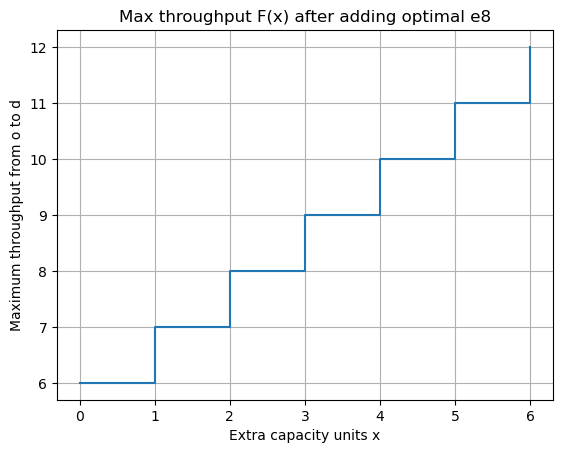

In [8]:
# Run the complete process with e8 and extra capacity
s, t = 'o', 'd'
x = 6  # number of extra capacity units to distribute

G_final, history, F = plan_place_e8_and_allocate(DG, s, t, x=x, seed=42, verbose=True)

plot_throughput(F, title="Max throughput F(x) after adding optimal e8")